# Audio Classification with ResNet 🎤

## 1. Transform audio files to spectrograms (images)

In [5]:
import librosa
import matplotlib.pyplot as plt
from utils import *
from pathlib import Path
import torch
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import transforms, models
import csv
from PIL import Image
from torch import nn

In [6]:
audios_path = Path("datasets/ESC-50/audio")
images_path = Path("datasets/ESC-50/images")
audio_files = list(audios_path.glob("*.wav"))

n_mels = 128 # number of mel frequency bands
hop_length = 100 # number of samples between consecutive analysis frames
win_length = 200 #(smaller than n_fft) Each frame of audio is windowed by window().
n_fft = 1024 #length of the FFT window
fmax = 20000 # the frequency upper bound used to create mel bands

In [14]:
# EXECUTE JUST 1 TIME TO CREATE THE IMAGES !!
for audio_file in audio_files:
    print(f"Procesando: {audio_file.name}")

    audio, Fs = librosa.load(audio_file)
    sample_rate = Fs
    spectrogram = librosa.feature.melspectrogram(y=audio,
                                             sr=sample_rate,
                                             n_mels=n_mels,
                                             hop_length=hop_length,
                                             win_length = win_length,
                                             n_fft=n_fft,
                                             fmax=fmax)
    spectrogram = librosa.power_to_db(spectrogram)


    plt.figure(figsize=(6, 4))
    librosa.display.specshow(spectrogram)
    plt.axis("off")  # quita ejes para imagen limpia

    output_file = images_path / f"{audio_file.stem}.png"
    plt.savefig(output_file, bbox_inches='tight', pad_inches=0)
    plt.close()  # cierra la figura para no sobrecargar memoria

    print(f"Guardado: {output_file}")

Procesando: 1-69165-A-34.wav
Guardado: datasets/ESC-50/images/1-69165-A-34.png
Procesando: 2-102414-E-17.wav
Guardado: datasets/ESC-50/images/2-102414-E-17.png
Procesando: 2-81970-A-7.wav
Guardado: datasets/ESC-50/images/2-81970-A-7.png
Procesando: 1-84704-A-39.wav
Guardado: datasets/ESC-50/images/1-84704-A-39.png
Procesando: 3-197408-A-8.wav
Guardado: datasets/ESC-50/images/3-197408-A-8.png
Procesando: 1-22694-A-20.wav
Guardado: datasets/ESC-50/images/1-22694-A-20.png
Procesando: 4-255371-A-47.wav
Guardado: datasets/ESC-50/images/4-255371-A-47.png
Procesando: 1-24524-C-19.wav
Guardado: datasets/ESC-50/images/1-24524-C-19.png
Procesando: 2-106486-A-44.wav
Guardado: datasets/ESC-50/images/2-106486-A-44.png
Procesando: 4-172143-A-13.wav
Guardado: datasets/ESC-50/images/4-172143-A-13.png
Procesando: 4-188703-D-8.wav
Guardado: datasets/ESC-50/images/4-188703-D-8.png
Procesando: 5-211197-A-24.wav
Guardado: datasets/ESC-50/images/5-211197-A-24.png
Procesando: 5-243783-A-44.wav
Guardado: data

In [7]:
num_images = len(list(images_path.glob("*.png")))
print("Número de imágenes guardadas:", num_images)

Número de imágenes guardadas: 2000


## 2. Create Dataset class

In [8]:
class ESC50Dataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

## 3. Assign the image (with file name) to the target (csv) and transform it

In [9]:
csv_path = Path("datasets/ESC-50/meta/esc50.csv")

data = []

with open(csv_path, newline='', encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        wav_name = row["filename"]
        target = int(row["target"])

        png_name = wav_name.replace(".wav", ".png")
        img_path = images_path / png_name

        if img_path.exists():
            data.append((img_path, target))

print("Example:", data[:5])
print("Total image-label:", len(data))


Example: [(PosixPath('datasets/ESC-50/images/1-100032-A-0.png'), 0), (PosixPath('datasets/ESC-50/images/1-100038-A-14.png'), 14), (PosixPath('datasets/ESC-50/images/1-100210-A-36.png'), 36), (PosixPath('datasets/ESC-50/images/1-100210-B-36.png'), 36), (PosixPath('datasets/ESC-50/images/1-101296-A-19.png'), 19)]
Total image-label: 2000


In [10]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = ESC50Dataset(data, transform=transform)

print(len(dataset))

img, label = dataset[0]
print("Label:", label)
print("Image type:", type(img))

2000
Label: 0
Image type: <class 'torch.Tensor'>


## 4. Split train and test and Data Loaders

In [11]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [12]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

## 5. Create Model

In [18]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using {device}")

model = models.resnet50(pretrained=True)

model.fc = torch.nn.Linear(model.fc.in_features, 50)

model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

num_epochs = 10

Using cuda


## 6. Train Model

In [13]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {running_loss:.4f} | Train Acc: {train_acc:.2f}%")


Epoch 1/10 | Loss: 290.8451 | Train Acc: 28.06%
Epoch 2/10 | Loss: 140.6240 | Train Acc: 65.12%
Epoch 3/10 | Loss: 76.6988 | Train Acc: 81.75%
Epoch 4/10 | Loss: 47.2553 | Train Acc: 88.44%
Epoch 5/10 | Loss: 27.4594 | Train Acc: 94.44%
Epoch 6/10 | Loss: 21.6387 | Train Acc: 95.69%
Epoch 7/10 | Loss: 15.7706 | Train Acc: 96.38%
Epoch 8/10 | Loss: 9.8679 | Train Acc: 98.50%
Epoch 9/10 | Loss: 9.3849 | Train Acc: 97.94%
Epoch 10/10 | Loss: 9.3226 | Train Acc: 98.31%


## 7. Test Model

In [14]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
print(correct)
print(total)
test_acc = 100 * correct / total
print(f"\nTest Accuracy: {test_acc:.2f}%")


321
400

Test Accuracy: 80.25%


In [14]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
print(correct)
print(total)
test_acc = 100 * correct / total
print(f"\nTest Accuracy: {test_acc:.2f}%")


321
400

Test Accuracy: 80.25%


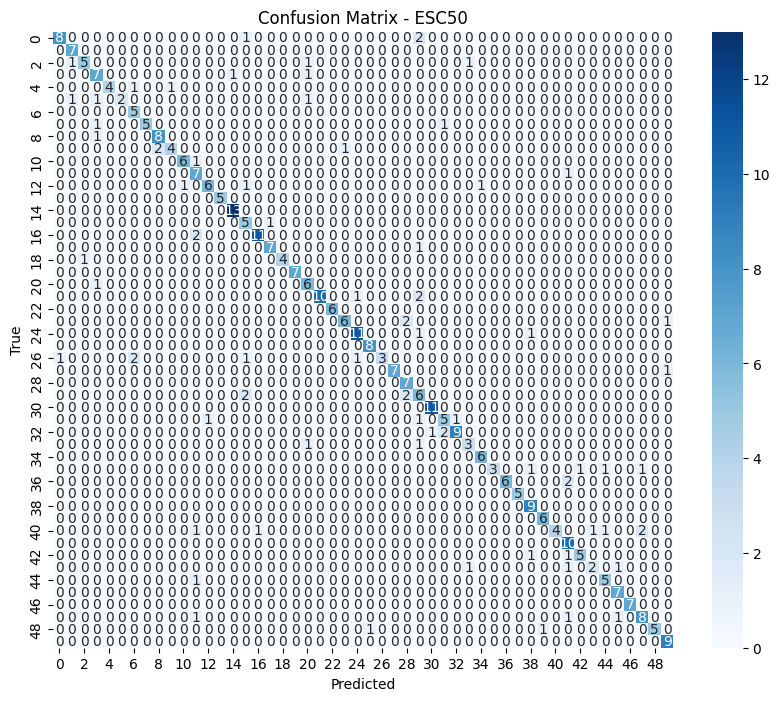

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import torch

all_labels = []
all_preds = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - ESC50")
plt.show()

## 8. Train - Test V.2

In [19]:
def train_loop(dataloader, model, loss_fn, optimizer, device):
    model.train()

    correct = 0
    total = 0
    running_loss = 0.0

    for X, y in dataloader:
        X = X.to(device)
        y = y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        running_loss += loss.item()
        correct += (pred.argmax(1) == y).sum().item()
        total += y.size(0)

    acc = 100 * correct / total
    print(f"Train Loss: {running_loss:.4f} | Train Acc: {acc:.2f}%")


In [20]:
def test_loop(dataloader, model, loss_fn, device):
    model.eval()
    size = len(dataloader.dataset)

    correct = 0
    test_loss = 0.0

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)

            pred = model(X)
            test_loss += loss_fn(pred, y).item()

            correct += (pred.argmax(1) == y).sum().item()

    test_loss /= len(dataloader)
    acc = 100 * correct / size

    print(f"Test Accuracy: {acc:.2f}% | Avg loss: {test_loss:.4f}\n")

In [23]:
for t in range(num_epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_loader, model, criterion, optimizer, device)
    test_loop(test_loader, model, criterion, device)

print("Done!")


Epoch 1
-------------------------------
Train Loss: 288.3665 | Train Acc: 29.06%
Test Accuracy: 52.50% | Avg loss: 1.7615

Epoch 2
-------------------------------
Train Loss: 136.4341 | Train Acc: 66.44%
Test Accuracy: 66.50% | Avg loss: 1.2167

Epoch 3
-------------------------------
Train Loss: 76.8933 | Train Acc: 81.62%
Test Accuracy: 74.75% | Avg loss: 0.9386

Epoch 4
-------------------------------
Train Loss: 41.2502 | Train Acc: 91.19%
Test Accuracy: 73.00% | Avg loss: 0.8868

Epoch 5
-------------------------------
Train Loss: 27.5419 | Train Acc: 94.12%
Test Accuracy: 75.75% | Avg loss: 0.8084

Epoch 6
-------------------------------
Train Loss: 19.0100 | Train Acc: 96.69%
Test Accuracy: 75.25% | Avg loss: 0.8048

Epoch 7
-------------------------------
Train Loss: 14.5131 | Train Acc: 97.25%
Test Accuracy: 72.25% | Avg loss: 0.8998

Epoch 8
-------------------------------
Train Loss: 14.5459 | Train Acc: 96.69%
Test Accuracy: 70.25% | Avg loss: 1.0690

Epoch 9
--------------